In [11]:
# At the very top of notebooks/1_data_extraction.ipynb
print("script started")
import sys, os
import pandas as pdp
from datasets import Dataset, DatasetDict, load_from_disk
# Insert project_root (one level up) onto the import path
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
import numpy as np
import yaml
# from utils.dataset_utils import create_dataset, create_dataset_dict, create_tokenizer
from src.data_extractor import extract_data, save_huggingface_dataset, load_dfs


script started


In [12]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/_Liver-Hepatocytes_window/R3_plain_500m_human_ref_train")

In [ ]:
import pandas as pd
import sys, os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
from src.utils.bigwig_utils import get_preprocessed_encode_cpg_dataframe
"""/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000R3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000T3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z00000431_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000043Q_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000044H_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000044M_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv"""
df = pd.read_csv("/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000R3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv")


In [6]:
preprocessed = get_preprocessed_encode_cpg_dataframe("/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig",chroms=[
    "chr1",
    "chr2",
    "chr3",
    "chr4",
    "chr5",
    "chr22",
    "chr21",
    "chr20",
    "chr19",
    "chr18",
])

In [3]:
paths = '''/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652190_Liver-Endothelium-Z000000RB.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652234_Liver-Hepatocytes-Z000000T3.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652235_Liver-Hepatocytes-Z0000043Q.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652236_Liver-Hepatocytes-Z0000044H.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652237_Liver-Hepatocytes-Z0000044M.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652238_Liver-Hepatocytes-Z00000431.hg38.bigwig
/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652307_Liver-Macrophages-Z0000043P.hg38.bigwig'''.split("\n")
dfs = load_dfs(paths,["chr1",
    "chr2",
    "chr3",
    "chr4",
    "chr5",
    # "chr22",
    # "chr21",
    # "chr20",
    # "chr19",
    # "chr18",
],"full_position",False)

In [4]:
import pandas as pd
paths = """/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000R3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000T3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z00000431_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000043Q_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000044H_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv
/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000044M_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv""".split("\n")

dfs = list(map(pd.read_csv,paths))

In [30]:
target = 5
sets = []
for i in range(len(dfs)):
    max_std = (dfs[i]["std"].max())
    target = 5
    curr_df = dfs[i]
    # for j in range(target):
    #     low = (max_std/target) * j
    #     high = (max_std/target) * (j+1)
    #     print(curr_df[(curr_df["std"] > low) & (curr_df["std"] > high)])
    low = (max_std/target) * 3
    high = (max_std/target) * (4)
    sets.append(set(curr_df[(curr_df["std"] > low) & (curr_df["std"] < high)]["full_position"]))
    

In [31]:
count_dict = {}
for i in range(len(sets)):
    for val in sets[i]:
        if val not in count_dict:
            count_dict[val] = 0
        count_dict[val]+=1


In [32]:
from collections import Counter
Counter(count_dict.values())

Counter({5: 39211, 1: 22859, 4: 18261, 3: 12055, 2: 8510, 6: 1748})

In [33]:
len(count_dict)

102644

<Axes: >

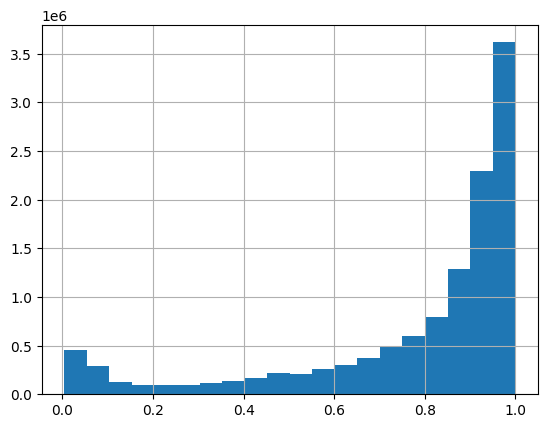

In [3]:
# cpg hist
preprocessed["methyl_rate"].hist(bins=20)

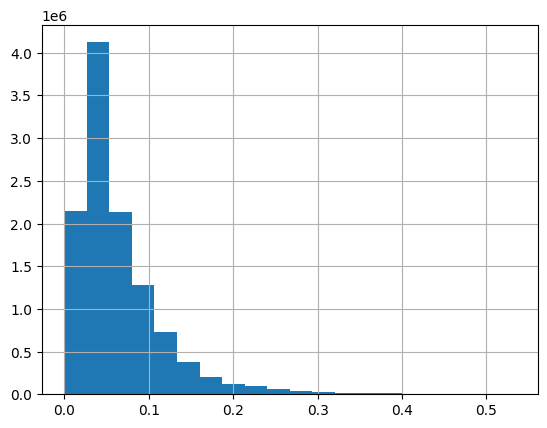

In [8]:
# cpg std hist
std_max = df["std"].hist(bins=20)

In [10]:
# std std
df["std"].std()

0.05178887633862541

In [ ]:
std_max = df["std"].max()
for i in range(5):
    low = (std_max/5) * i
    high = (std_max/5) * (i+1)
    filtered = df[(df["std"] > low) & (df["std"] <= high)]
    

0           0.10455
1           0.07947
2           0.05603
3           0.05100
6           0.08374
             ...   
11378370    0.07336
11378371    0.03750
11378372    0.07227
11378378    0.08716
11378382    0.10480
Name: std, Length: 9662245, dtype: float64
4           0.14270
5           0.13050
8           0.15650
10          0.18480
12          0.14810
             ...   
11378376    0.12920
11378377    0.13220
11378379    0.10767
11378380    0.12710
11378381    0.13390
Name: std, Length: 1429547, dtype: float64
11          0.2261
15          0.2185
16          0.2319
38          0.2252
61          0.3118
             ...  
11378325    0.2637
11378326    0.2374
11378335    0.2277
11378340    0.2563
11378367    0.2935
Name: std, Length: 210860, dtype: float64
169         0.3254
374         0.3384
560         0.3801
820         0.3613
1010        0.3313
             ...  
11376471    0.4230
11376557    0.3342
11376572    0.3826
11376579    0.3823
11376584    0.3960
Name: std, Len

0.534

In [2]:
from datasets import load_dataset
ds = load_dataset("OpenMed/pgc-schizophrenia", "scz2022")


DatasetNotFoundError: Dataset 'OpenMed/pgc-schizophrenia' doesn't exist on the Hub or cannot be accessed.

In [1]:
import yaml
import sys, os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))

# from utils.dataset_utils import create_dataset, create_dataset_dict, create_tokenizer
import src.data_extractor
from src.data_extractor import extract_data
import importlib
importlib.reload(src.data_extractor)
config_path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/data_extraction_with_token_filtering.yaml"
cfg = yaml.safe_load(open(config_path))
 
res = extract_data(cfg)


started program!!
finished loading variability dict
started extracting CpG data
Processing chromosome: chr5 with length: 181538259
Extracted 1445774 CpG values from raw data.
Creating intermediate dataframes from pre-processed data.


/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/src/utils/formatting.py:218: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["seq"] = df.apply(apply_add_sequence_formultiple_instance_format_df_wrapper(chrom_dict),axis=1)


Saving intermediate data to /sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train2025-10-1313:43:15.974316abcd.csv and /sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-1313:43:15.974316abcd.csv.
Creating Hugging Face dataset from intermediate data.


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/32489 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/32489 [00:00<?, ? examples/s]

Map:   0%|          | 0/30617 [00:00<?, ? examples/s]

Map:   0%|          | 0/32489 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/30617 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/32489 [00:00<?, ? examples/s]

In [ ]:
# arr = np.array([0.3,0.4,-100,-100,-100,-100,0.2,1,-100,0.3,-100,-100,-100,-100,0.2,0.1,-100,-100,-100,-100,0.4,0.1,0.1,-100,-100,-100,-100,0.2,-100,-100,0.3,-100,-100,-100,-100,0.2,0.1,-100,-100,-100,-100,0.4,0.1,0.1] * 30)
# empty_label = -100
# p = 0.8


# def create_kmer_split_train_test_labels(lable_array, empty_label, p,random_seed):
#     mask = lable_array!=empty_label
#     a = mask.copy()
#     b = mask.copy()
#     idx = np.flatnonzero(mask) 
#     rng = np.random.default_rng(random_seed)
#     rng.shuffle(idx)
#     cut = int(p * idx.size)
#     idx_a_false = idx[:cut]
#     idx_b_false = idx[cut:]
#     a.ravel()[idx_a_false] = False
#     b.ravel()[idx_b_false] = False

#     arr_train = lable_array.copy()
#     arr_test = lable_array.copy()
#     arr_train[a] = empty_label
#     arr_test[b] = empty_label
#     return arr_train,arr_test

# # arr_train, arr_test = create_kmer_split_train_test_labels(arr, empty_label, p,42)

# df = pd.DataFrame([["a",arr],["b",arr],["c",arr]],columns=["name","labels"])
# def apply_seperate_window_labels_wrapper(empty_label, p,random_seed):
#     def apply_seperate_window_labels(row):
#         labels = np.array(row["labels"])
#         return create_kmer_split_train_test_labels(labels,empty_label,p,random_seed)
#         # return 2,3
#     return apply_seperate_window_labels
# df[["train_labels","test_labels"]] = df.apply(apply_seperate_window_labels_wrapper(-100,0.8,42),axis=1,result_type="expand")
# df
# # print(len(arr_train[arr_train!=-100]))
# # print(len(arr_test[arr_test!=-100]))
# # print(len(arr[arr!=-100]))
# # print(len(arr))

In [1]:
from datasets import load_from_disk, concatenate_datasets
a = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/_new_lo_test/R3_retrain_new_lo_test_datasets_train")
b = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/_new_lo_test/R3_retrain_new_lo_test_datasets_test")



In [20]:
901 - b[3]["labels"].count(-100)

6

In [19]:
901 - a[3]["labels"].count(-100)

23

In [2]:
from datasets import load_from_disk
my_ds = load_from_disk("/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000T3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv")

# other_ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_chr5_kmer_sample_filtration_train_second_attampt")

FileNotFoundError: Directory /sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z000000T3_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv is neither a `Dataset` directory nor a `DatasetDict` directory.

In [8]:
my_ds

Dataset({
    features: ['seq', 'start', 'end', 'window_id', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 142913
})

In [8]:
lst = []
for i in range(len(my_ds)):
    lst.append( 901 - my_ds[i]["labels"].count(-100.0))
    

In [21]:
other_lst = []
for i in range(len(other_ds)):
    other_lst.append( 901 - other_ds[i]["labels"].count(-100.0))
    

In [9]:
import pandas as pd

In [27]:
df= pd.DataFrame(lst)
df.describe()

,0
count,32883.000000
mean,34.120092
std,20.603299
min,1.000000
25%,21.000000
50%,28.000000
75%,40.000000
max,229.000000


In [23]:
df2 = pd.DataFrame(other_lst)

In [28]:
df2.describe()

,0
count,32672.000000
mean,8.082272
std,5.132867
min,1.000000
25%,5.000000
50%,7.000000
75%,10.000000
max,57.000000


In [ ]:
for i in range(len(1,20)):
    print(i)
    print("test",len(df[df[0] == i]))
    print("train",len(df2[df2[0] == i]))


68

In [16]:
df = pd.read_csv("/sci/archive/mi   chall/roeizucker/huggingface_datasets_dir/temp_kmer_sample_filtration.csv")

In [17]:
df["split_labels"] = df["labels"].str.strip("[]").str.split(", ")
df["split_train_labels"] = df["train_labels"].str.strip("[]").str.split(", ")
df["split_test_labels"] = df["test_labels"].str.strip("[]").str.split(", ")

In [18]:
for row in df[["split_train_labels","split_test_labels"]].iterrows():
    a = np.array(row[1]["split_train_labels"],dtype=float)
    b = np.array(row[1]["split_test_labels"],dtype=float)
    print(len(a))
    mask = (a!=-100) & (b!=-100)
    if len(a[mask]) > 0:
        print(len(a[a!=-100]), len(b[b!=-100]), a[mask])

5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5401
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400
5400


KeyboardInterrupt: 

In [3]:
from datasets import load_from_disk
ds1 = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_chr1-10_kmer_sample_filtration_train")
ds2 = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_chr1-10_kmer_sample_filtration_test")

In [8]:
import pandas as pd
df1 = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train2025-10-1313:43:15.974316abcdyo.csv")
df2 = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-1313:43:15.974316.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-1313:43:15.974316.csv'

In [ ]:
def create_kmer_split_train_test_labels(lable_array, empty_label, p,random_seed):
    mask = lable_array!=empty_label
    a = mask.copy()
    b = mask.copy()
    idx = np.flatnonzero(mask) 
    rng = np.random.default_rng(random_seed)
    rng.shuffle(idx)
    cut = int(p * idx.size)
    idx_a_false = idx[:cut]
    idx_b_false = idx[cut:]
    a.ravel()[idx_a_false] = False
    b.ravel()[idx_b_false] = False

    arr_train = lable_array.copy()
    arr_test = lable_array.copy()
    arr_train[a] = empty_label
    arr_test[b] = empty_label
    return list(arr_train),list(arr_test)

def map_seperate_window_labels_wrapper(empty_label, p,random_seed):
    def apply_seperate_window_labels(row):
        labels = np.array(row["labels"])
        labels_train, labels_test = create_kmer_split_train_test_labels(labels,empty_label,p,random_seed)
        return {"train_labels": labels_train, "test_labels": labels_test}
        # return create_kmer_split_train_test_labels(labels,empty_label,p,random_seed)
        
    return apply_seperate_window_labels
aaaa = ds1.map(map_seperate_window_labels_wrapper(-100,0.8,42))

Map:   0%|          | 0/32489 [00:00<?, ? examples/s]

In [ ]:
train_ds = aaaa.remove_columns(["test_labels","labels"]).rename_column("train_labels","labels")
test_ds = aaaa.remove_columns(["train_labels","labels"]).rename_column("test_labels","labels")

AttributeError: 'Dataset' object has no attribute 'copy'

In [10]:
a = np.array(df1["labels"][0].strip("[]").split(", "), dtype=float)
b = np.array(df2["labels"][0].strip("[]").split(", "), dtype=float)
mask = (a!=-100) & (b!=-100)
print(len(a[a!=-100]), len(b[b!=-100]), a[mask])

4 18 []


In [5]:
a = df1["labels"][0]
b = df2["labels"][0]


NameError: name 'df1' is not defined

In [34]:
lst = df1["labels"][0].strip("[]").split(", ")
for i in range(0,len(lst),6):
    print(i // 6,lst[i:i+6])

0 ['-100', '-100', '-100', '-100', '-100', '-100']
1 ['-100', '-100', '0.93212890625', '0.93212890625', '-100', '-100']
2 ['-100', '-100', '-100', '-100', '-100', '-100']
3 ['-100', '-100', '-100', '-100', '-100', '-100']
4 ['-100', '-100', '-100', '-100', '-100', '-100']
5 ['-100', '-100', '-100', '-100', '-100', '-100']
6 ['-100', '-100', '-100', '-100', '-100', '-100']
7 ['-100', '-100', '-100', '-100', '-100', '-100']
8 ['-100', '-100', '-100', '-100', '-100', '-100']
9 ['-100', '-100', '-100', '-100', '-100', '-100']
10 ['-100', '-100', '-100', '-100', '-100', '-100']
11 ['-100', '-100', '-100', '-100', '-100', '-100']
12 ['-100', '-100', '-100', '-100', '-100', '-100']
13 ['-100', '-100', '-100', '-100', '-100', '-100']
14 ['-100', '-100', '-100', '-100', '-100', '-100']
15 ['-100', '-100', '-100', '-100', '-100', '-100']
16 ['-100', '-100', '-100', '-100', '-100', '-100']
17 ['-100', '-100', '-100', '-100', '-100', '-100']
18 ['-100', '-100', '-100', '-100', '-100', '-100']
19 [

In [44]:
dsa = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_chr1-10_kmer_sample_filtration_train_other")
dsb = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_chr1-10_kmer_sample_filtration_test_other")

In [ ]:
for i in range(len(dsb[0]["labels"])):
    if dsb[0]["labels"][i] != -100:
        

2 0.93212890625
63 0.97998046875
80 0.955078125
87 0.97607421875
102 0.966796875
113 0.96923828125
121 0.865234375
123 0.97412109375
156 0.97705078125
195 1.0
237 0.97607421875
240 0.951171875
243 0.97119140625
266 0.9560546875
341 0.92578125
367 0.96484375
408 0.951171875
412 1.0
418 0.9658203125
488 0.953125
497 0.97802734375
503 0.93212890625
504 0.9248046875
515 0.97021484375
517 0.94091796875
519 0.428955078125
564 0.98095703125
569 0.87890625
597 0.76318359375
621 0.98193359375
638 0.89599609375
665 0.5849609375
721 1.0
724 0.9532877802848816
729 0.93505859375
735 0.97900390625
746 0.9111328125
786 0.63623046875
798 0.6181640625
807 0.85693359375
856 0.9091796875


In [57]:
import numpy as np
for i in range(20):
    # if ds1[i]["window_id"] != ds2[i]["window_id"]:
    #     print("window ids do not match!")
    #     break
    # ds1_0_arr = np.array(ds1[i]["labels"])
    ds2_0_arr = np.array(dsb[i]["labels"])
    
    # print(ds1_0_arr[ds1_0_arr!=-100])
    a = (ds2_0_arr[ds2_0_arr!=-100])
    repeat_count = 0
    for j in range(len(a) - 1):
        if a[j] == a[j+1]:
            repeat_count+=1
    print(f"Number of repeats in sample {i}: {repeat_count}, out of {len(a)} valid labels")
    print(a)
    print("#"*30)

Number of repeats in sample 0: 0, out of 41 valid labels
[0.93212891 0.97998047 0.95507812 0.97607422 0.96679688 0.96923828
 0.86523438 0.97412109 0.97705078 1.         0.97607422 0.95117188
 0.97119141 0.95605469 0.92578125 0.96484375 0.95117188 1.
 0.96582031 0.953125   0.97802734 0.93212891 0.92480469 0.97021484
 0.94091797 0.42895508 0.98095703 0.87890625 0.76318359 0.98193359
 0.89599609 0.58496094 1.         0.95328778 0.93505859 0.97900391
 0.91113281 0.63623047 0.61816406 0.85693359 0.90917969]
##############################
Number of repeats in sample 1: 0, out of 26 valid labels
[0.71386719 0.61083984 0.52197266 0.51123047 0.5        0.93994141
 0.64208984 0.88085938 0.84049481 0.78417969 0.76123047 0.58496094
 0.82080078 0.35009766 0.33300781 0.53808594 0.66699219 0.76123047
 0.77294922 0.32592773 0.83984375 0.76708984 0.75       0.76904297
 0.26708984 0.9140625 ]
##############################
Number of repeats in sample 2: 5, out of 91 valid labels
[0.83691406 1.         0

In [7]:
ds2

Dataset({
    features: ['seq', 'start', 'end', 'window_id', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 32489
})

In [5]:
import sys, os
import pandas as pd
from datasets import Dataset, DatasetDict, load_from_disk
# Insert project_root (one level up) onto the import path
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
from src.data_extractor import get_preprocessed_encode_cpg_dataframe ,create_length_window_id, create_labels_formultiple_instance_format_df
from src.utils.bigwig_utils import cpg_values_generator
preprocessed_df = get_preprocessed_encode_cpg_dataframe("/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig",["chr5"],remove_under_0=True,verbose=True)

Processing chromosome: chr5 with length: 181538259


In [6]:
import pyBigWig
bw = pyBigWig.open("/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig")
df = pd.DataFrame(
            cpg_values_generator(bw, ["chr5"], True),
            columns=["start", "end", "methyl_rate", "chrom"],
        )

Processing chromosome: chr5 with length: 181538259


In [10]:
len(df[df["methyl_rate"] < 0])/len(df)

0.04946075255260814

In [ ]:
from src.data_extractor import create_methyl_variability_df, combine_cpg_dfs, load_dfs
raw_files_paths = [
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652235_Liver-Hepatocytes-Z0000043Q.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652236_Liver-Hepatocytes-Z0000044H.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652237_Liver-Hepatocytes-Z0000044M.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652238_Liver-Hepatocytes-Z00000431.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652234_Liver-Hepatocytes-Z000000T3.hg38.bigwig",
]
chroms = [ "chr1"]
dfs = load_dfs(raw_files_paths, chroms, "full_position",False)
labels = []  # same length/order as `kept`
for i in range(len(dfs)):
    labels.append(f"ind_{i}")

df = combine_cpg_dfs("full_position", dfs, labels)
res_df = create_methyl_variability_df(len(dfs), df,"std","quantile",0.05)

max_diff_quantile_value 0.015960693359375


In [ ]:
# ds[119000]["window_id"]

'chr3:142192800-142198200'

In [4]:
# np.array(res_df[res_df["window_id"] == "chr3:142192800-142198200"]["methyl_rate_ind_0"])

In [5]:
# curr_arr = np.array(ds[119000]["labels"])
# curr_arr[curr_arr!= -100]

In [ ]:
# import numpy as np
# from  utils.metrics_utils import(
#     pearsonr_eval,
#     mse,
#     mae
# )

# low = 0.48123
# high = 0.5347
# a = res_df[(res_df["std"] > low) & (res_df["std"] < high)]["methyl_rate_ind_0"]
# b = res_df[(res_df["std"] > low) & (res_df["std"] < high)][["methyl_rate_ind_1","methyl_rate_ind_2","methyl_rate_ind_3","methyl_rate_ind_4"]]

# a = np.array(a)
# b = np.array(b)
# b = b.mean(axis=1)
# pearsonr_eval.compute(predictions=a,references=b)


{'pearsonr': -0.7091421106807817}

In [ ]:
# ds[0]["window_id"]

'chr10:100002600-100008000'

In [2]:
from src.evaluator import create_variability_positions_dict
def chrom1_filter(row):
    return "chr1" in row["window_id"]
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_all_chr1-10_train")

ds = ds.filter(chrom1_filter)
variant_file_dataframe = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_per_varaint_variability_after_HPO_lr_06_bs_2_chr1-10.csv").dropna()

variant_file_dataframe = variant_file_dataframe[variant_file_dataframe["window_id"].str.contains("chr1:")]
def add_std_bins_to_dataframe(number_of_bins, variant_file_dataframe):
    max_val = variant_file_dataframe["std"].max()
    edges = list(np.linspace(0,max_val,number_of_bins + 1))
        # labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
    labels = []
    for i in range(len(edges) - 1):
        labels.append(f"{edges[i]}-{edges[i+1]}")
    variant_file_dataframe["std_bin"] = pd.cut(
            variant_file_dataframe["std"],                # your std-dev column
            bins=edges,
            labels=labels,
            right=True,               # (a, b]
            include_lowest=True  
                 # include 0 in first bin
            )
add_std_bins_to_dataframe(10, variant_file_dataframe)
bins_to_use = variant_file_dataframe["std_bin"].unique()
window_ids_in_variant_file = set(variant_file_dataframe["window_id"].unique())
# variability_positions_dict = create_variability_positions_dict(True, new_ds, bins_to_use, variant_file_dataframe)
variability_positions_dict = create_variability_positions_dict(True, ds, bins_to_use, variant_file_dataframe)
# variant_file_dataframe

2026-01-10 20:58:30.772786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-10 20:58:30.785044: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-10 20:58:30.788771: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 20:58:30.797942: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-10 20:58:33.810820: W tensorflow/compiler/tf2

Filter:   0%|          | 0/323401 [00:00<?, ? examples/s]

created variants bin based variant dictionary
mapping viable variants 66300 / 66334


In [3]:
def create_dataset_labels(selected_dataset, variability_positions_dict, bins_to_use):
    dataset_labels = {}
    for dataset_index in range(len(selected_dataset)):
        if dataset_index % 1000 == 0:
            print(dataset_index,"/",len(selected_dataset),end="\r")
        curr_window_id =selected_dataset[dataset_index]["window_id"]
        if curr_window_id not in dataset_labels:
            dataset_labels[curr_window_id] = {}
        for curr_bin in bins_to_use:
            if curr_bin not in variability_positions_dict[curr_window_id]:
                continue
            
            viable_positions = variability_positions_dict[curr_window_id][curr_bin]
                # add +1 to labels position because first token is for entire sequence, so all needs to be shifted
            filtered_labels_from_dataset = [ selected_dataset[dataset_index]["labels"][i + 1] for i in viable_positions]   
            dataset_labels[curr_window_id][curr_bin] = filtered_labels_from_dataset
    return dataset_labels

dataset_labels = create_dataset_labels(ds, variability_positions_dict, bins_to_use)


In [ ]:
curr_bin = '0.47457-0.5273'
true_labels = []
for curr_window_id in dataset_labels:
    if curr_bin in dataset_labels[curr_window_id] and len(dataset_labels[curr_window_id][curr_bin]) > 0:
        print(dataset_labels[curr_window_id][curr_bin])
        break

[0.327880859375]


In [5]:
new_ds = ds.select(range(34415,34415+1))

In [8]:
variability_positions_dict['chr1:16696800-16702200'].keys()

dict_keys(['0.05273-0.10546', '0.0-0.05273', '0.10546-0.15819', '0.15819-0.21092', '0.21092-0.26365', '0.26365-0.31638', '0.31638-0.36911', '0.36911-0.42184', '0.42184-0.47457', '0.47457-0.5273'])

In [5]:
# new_ds = ds.select(range(34415,34415+1))
print(len(variability_positions_dict['chr1:16696800-16702200']['0.05273-0.10546']))
len(variant_file_dataframe[(variant_file_dataframe["window_id"] == "chr1:16696800-16702200") & (variant_file_dataframe["std_bin"] == "0.05273-0.10546")])

39


39

In [ ]:
# for i in range(len(ds)):
#     if ds[i]["window_id"] == "chr1:16696800-16702200":
#         print(i)
#         break


34415


In [ ]:
# def add_std_bins_to_dataframe(number_of_bins, variant_file_dataframe):
#     max_val = variant_file_dataframe["std"].max()
#     edges = list(np.linspace(0,max_val,number_of_bins + 1))
#         # labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
#     labels = []
#     for i in range(len(edges) - 1):
#         labels.append(f"{edges[i]}-{edges[i+1]}")
#     variant_file_dataframe["std_bin"] = pd.cut(
#             variant_file_dataframe["std"],                # your std-dev column
#             bins=edges,
#             labels=labels,
#             right=True,               # (a, b]
#             include_lowest=True  
#                  # include 0 in first bin
#             )
# # variant_file_dataframe = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_per_varaint_variability_after_HPO_lr_06_bs_2_chr1-10.csv").dropna()

# add_std_bins_to_dataframe(10, variant_file_dataframe)

# bins_to_use = variant_file_dataframe["std_bin"].unique()
# bins_to_use
# window_ids_in_variant_file = set(variant_file_dataframe["window_id"].unique())
# variability_positions_dict = create_variability_positions_dict(True, new_ds, bins_to_use, variant_file_dataframe)

created variants bin based variant dictionary
mapping viable variants 0 / 1


In [ ]:
# from src.evaluator import create_dataset_labels


In [9]:
len(dataset_labels["chr1:16696800-16702200"]["0.05273-0.10546"])

39

In [10]:
np.array(dataset_labels['chr1:16696800-16702200']['0.05273-0.10546'])

array([ 2.24975586e-01,  4.12109375e-01,  3.50097656e-01,  4.06982422e-01,
        3.85009766e-01,  9.90295410e-03,  6.11877441e-02,  2.60986328e-01,
        2.83935547e-01,  6.96044922e-01,  2.56103516e-01,  7.26928711e-02,
        8.82263184e-02,  9.30175781e-02,  1.04980469e-01,  1.76025391e-01,
        3.69873047e-02,  8.61816406e-02,  9.42077637e-02,  1.66992188e-01,
        1.34033203e-01,  6.93969727e-02,  1.93969727e-01,  5.27038574e-02,
        1.54037476e-02,  2.33001709e-02, -1.00000000e+02,  1.04003906e-01,
        5.16479492e-01,  5.16479492e-01,  5.44921875e-01,  7.13867188e-01,
        7.08007812e-01,  7.89062500e-01,  7.39990234e-01,  4.56054688e-01,
        8.96972656e-01,  9.52148438e-01,  1.00000000e+00])

In [ ]:
# len(np.array(dataset_labels["chr1:16696800-16702200"]["0.05347-0.10694"],dtype=np.float16))

40

In [12]:
from src.data_extractor import create_methyl_variability_df, combine_cpg_dfs, load_dfs
raw_files_paths = [
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig",
]
chroms = [ "chr1"]
dfs = load_dfs(raw_files_paths, chroms, "full_position",False)
labels = []  # same length/order as `kept`
for i in range(len(dfs)):
    labels.append(f"ind_{i}")

R3_df = combine_cpg_dfs("full_position", dfs, labels)
R3_df = create_methyl_variability_df(len(dfs), R3_df,"std","quantile",0.05)

max_diff_quantile_value nan


In [23]:
temp_full_pos = res_df.set_index("full_position")
temp_full_pos
temp_R3 = R3_df.set_index("full_position")
temp_R3["std"] = temp_full_pos["std"]
np.array(temp_R3[(temp_R3["window_id"] == "chr1:16696800-16702200") & (temp_R3["std"] > 0) & (temp_R3["std"] < 0.05273)]["methyl_rate_ind_0"])
# next step - look at this exact position for the atlas, compare to the variability. find out why it's not the same

array([0.243 , 0.23  , 0.125 , 0.17  , 0.135 , 0.0333, 0.108 , 0.186 ,
       0.956 , 0.979 , 0.381 , 0.0714, 0.0263, 0.183 , 0.974 , 0.945 ,
       0.918 , 0.937 , 0.951 , 0.967 ], dtype=float16)

In [19]:
np.array(dataset_labels['chr1:16696800-16702200']['0.0-0.05273'])

array([0.24304199, 0.22998047, 0.125     , 0.17004395, 0.13500977,
       0.03329468, 0.10797119, 0.18603516, 0.95605469, 0.97900391,
       0.38110352, 0.07141113, 0.02630615, 0.1829834 , 0.73999023,
       0.94482422, 0.91796875, 0.93701172, 0.95117188, 0.96679688])

In [ ]:
temp_R3[temp_R3["window_id"] == "chr1:16696800-16702200"]

,methyl_rate_ind_0,start,end,chrom,std,high_diff,bin_start,bin_end,window_id
full_position,,,,,,,,,
chr1:16696835-16696837,0.243042,16696835,16696837,chr1,0.048798,False,16696800,16702200,chr1:16696800-16702200
chr1:16696838-16696840,0.215942,16696838,16696840,chr1,0.078735,False,16696800,16702200,chr1:16696800-16702200
chr1:16696880-16696882,0.229980,16696880,16696882,chr1,0.008972,False,16696800,16702200,chr1:16696800-16702200
chr1:16696888-16696890,0.412109,16696888,16696890,chr1,0.104248,False,16696800,16702200,chr1:16696800-16702200
chr1:16696895-16696897,0.350098,16696895,16696897,chr1,0.065186,False,16696800,16702200,chr1:16696800-16702200
...,...,...,...,...,...,...,...,...,...
chr1:16701954-16701956,0.937012,16701954,16701956,chr1,0.032257,False,16696800,16702200,chr1:16696800-16702200
chr1:16702010-16702012,0.951172,16702010,16702012,chr1,0.040924,False,16696800,16702200,chr1:16696800-16702200
chr1:16702087-16702089,0.966797,16702087,16702089,chr1,0.040894,False,16696800,16702200,chr1:16696800-16702200


In [ ]:
lab = np.array(new_ds[0]["labels"])
lab[lab != -100][:20]

array([0.24304199, 0.22497559, 0.22998047, 0.41210938, 0.35009766,
       0.35009766, 0.3659668 , 0.125     , 0.40698242, 0.46289062,
       0.38500977, 0.38500977, 0.17004395, 0.00990295, 0.03059387,
       0.13500977, 0.06118774, 0.26098633, 0.26098633, 0.28393555])

In [244]:
np.array(temp_R3[temp_R3["window_id"] == "chr1:16696800-16702200"]["methyl_rate_ind_0"])[:20]

array([0.243 , 0.216 , 0.23  , 0.412 , 0.35  , 0.366 , 0.125 , 0.407 ,
       0.463 , 0.385 , 0.17  , 0.0099, 0.0306, 0.135 , 0.0612, 0.261 ,
       0.284 , 0.0333, 0.108 , 0.186 ], dtype=float16)

In [ ]:
# bins_to_use[0]
raw_files_paths

['/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652235_Liver-Hepatocytes-Z0000043Q.hg38.bigwig',
 '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652236_Liver-Hepatocytes-Z0000044H.hg38.bigwig',
 '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652237_Liver-Hepatocytes-Z0000044M.hg38.bigwig',
 '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652238_Liver-Hepatocytes-Z00000431.hg38.bigwig',
 '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652234_Liver-Hepatocytes-Z000000T3.hg38.bigwig']

In [13]:
# code atlas:
from evaluator import create_window_id_dataset_dict
atlas_dataset_paths = [
    "/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_all_chr1-10_train",
    "/sci/archive/michall/roeizucker/huggingface_datasets_dir/4H_all_chr1-10_train",
    "/sci/archive/michall/roeizucker/huggingface_datasets_dir/4M_all_chr1-10_train",
    "/sci/archive/michall/roeizucker/huggingface_datasets_dir/31_all_chr1-10_train",
    "/sci/archive/michall/roeizucker/huggingface_datasets_dir/T3_all_chr1-10_train"

]
atlas_datasets_to_use = []
for path in atlas_dataset_paths:
    atlas_datasets_to_use.append(load_from_disk(path))
    dataset_dicts_to_use = []
counter = 0
for val in atlas_datasets_to_use:
    print("creating atlas dict:",counter,"/",len(atlas_datasets_to_use),end="\r")
    counter+=1
    dic,temp_keys = create_window_id_dataset_dict(val)
    dataset_dicts_to_use.append(dic)

# low = 0.05273
# high = 0.10546
# b = res_df[(res_df["std"] > low) & (res_df["std"] < high) & (res_df["window_id"] == curr_window_id)][["methyl_rate_ind_0","methyl_rate_ind_1","methyl_rate_ind_2","methyl_rate_ind_3","methyl_rate_ind_4"]]
# b = np.array(b)
# b = b.mean(axis=1)
# b

In [38]:
curr_bin = '0.47457-0.5273'
from utils.metrics_utils import(
    pearsonr_eval,
    mse,
    mae
)

true_labels = []
prediction_lables = []
for curr_window_id in dataset_labels:
    if curr_bin in dataset_labels[curr_window_id] and len(dataset_labels[curr_window_id][curr_bin]) > 0:
        # print(dataset_labels[curr_window_id][curr_bin],curr_window_id)
        other_vals = []
        for dic in dataset_dicts_to_use:
            if curr_window_id in dic:
                other_vals.append(np.array(dic[curr_window_id]["labels"]))

        other_vals = np.array(other_vals)
        other_vals[other_vals == -100] = np.nan
        predictions = list(np.nanmean(other_vals,axis=0))
        viable_positions = variability_positions_dict[curr_window_id][curr_bin]
        filtered_from_prediction = [ predictions[i+1] for i in viable_positions]
        true_labels.extend(dataset_labels[curr_window_id][curr_bin])
        prediction_lables.extend(filtered_from_prediction)
        # if len(filtered_from_prediction) != len(dataset_labels[curr_window_id][curr_bin]):
        #     print(filtered_from_prediction,dataset_labels[curr_window_id][curr_bin])
        #     print("abcd")
        #     break
        # print(filtered_from_prediction)
        # break
pearsonr_eval.compute(predictions=prediction_lables,references=true_labels)

/tmp/ipykernel_2178786/3168973918.py:20: RuntimeWarning: Mean of empty slice
  predictions = list(np.nanmean(other_vals,axis=0))


{'pearsonr': -0.040417273596494746}

In [47]:
for curr_bin in bins_to_use:
    true_labels = []
    prediction_lables = []
    for curr_window_id in dataset_labels:
        if curr_bin in dataset_labels[curr_window_id] and len(dataset_labels[curr_window_id][curr_bin]) > 0:
            other_vals = []
            for dic in dataset_dicts_to_use:
                if curr_window_id in dic:
                    other_vals.append(np.array(dic[curr_window_id]["labels"]))
            if len(other_vals) == 0:
                continue
            other_vals = np.array(other_vals)
            other_vals[other_vals == -100] = np.nan
            predictions = list(np.nanmean(other_vals,axis=0))
            viable_positions = variability_positions_dict[curr_window_id][curr_bin]
            filtered_from_prediction = [ predictions[i+1] for i in viable_positions]
            true_labels.extend(dataset_labels[curr_window_id][curr_bin])
            prediction_lables.extend(filtered_from_prediction)
            # if len(filtered_from_prediction) != len(dataset_labels[curr_window_id][curr_bin]):
            #     print(filtered_from_prediction,dataset_labels[curr_window_id][curr_bin])
            #     print("abcd")
            #     break
            # print(filtered_from_prediction)
            # break
    # print(curr_bin,pearsonr_eval.compute(predictions=prediction_lables,references=true_labels),flush=True)
    labels_from_dataset = np.array(true_labels)
    labels_from_prediction = np.array(prediction_lables)
    mask = (labels_from_dataset!=-100)
    labels_from_dataset = labels_from_dataset[mask]
    labels_from_prediction = labels_from_prediction[mask]
    mask = ~(np.isnan(labels_from_dataset) | np.isnan(labels_from_prediction))
            # NOTE: make sure this works
    labels_from_prediction = labels_from_prediction[mask]
    labels_from_dataset = labels_from_dataset[mask]
    print(curr_bin,pearsonr_eval.compute(predictions=labels_from_prediction,references=labels_from_dataset))

/tmp/ipykernel_2178786/1921297269.py:14: RuntimeWarning: Mean of empty slice
  predictions = list(np.nanmean(other_vals,axis=0))


0.05273-0.10546 {'pearsonr': 0.8738664193181136}
0.0-0.05273 {'pearsonr': 0.9301091294237803}
0.10546-0.15819 {'pearsonr': 0.7135402635604075}
0.15819-0.21092 {'pearsonr': 0.5869143969046513}
0.21092-0.26365 {'pearsonr': 0.54931998064835}
0.26365-0.31638 {'pearsonr': 0.49818005267007825}
0.31638-0.36911 {'pearsonr': 0.4119430503705326}
0.36911-0.42184 {'pearsonr': 0.39076364223269283}
0.42184-0.47457 {'pearsonr': 0.3946061153843998}
0.47457-0.5273 {'pearsonr': 0.18234184717198565}


In [3]:
import sys, os
import pandas as pd
# from datasets import Dataset, DatasetDict, load_from_disk
# Insert project_root (one level up) onto the import path
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
from src.data_extractor import create_methyl_variability_df, combine_cpg_dfs, load_dfs

raw_files_paths = [
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652235_Liver-Hepatocytes-Z0000043Q.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652236_Liver-Hepatocytes-Z0000044H.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652237_Liver-Hepatocytes-Z0000044M.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652238_Liver-Hepatocytes-Z00000431.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652234_Liver-Hepatocytes-Z000000T3.hg38.bigwig",
]
chroms = [ "chr1"]
dfs = load_dfs(raw_files_paths, chroms, "full_position",True)
labels = []  # same length/order as `kept`
for i in range(len(dfs)):
    labels.append(f"ind_{i}")

df = combine_cpg_dfs("full_position", dfs, labels)

start loading
['/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652233_Liver-Hepatocytes-Z000000R3.hg38.bigwig', '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652235_Liver-Hepatocytes-Z0000043Q.hg38.bigwig', '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652236_Liver-Hepatocytes-Z0000044H.hg38.bigwig', '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652237_Liver-Hepatocytes-Z0000044M.hg38.bigwig', '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652238_Liver-Hepatocytes-Z00000431.hg38.bigwig', '/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652234_Liver-Hepatocytes-Z000000T3.hg38.bigwig']
Processing chromosome: chr1 with length: 248956422
Processing chromosome: chr1 with length: 248956422
Processing chromosome: chr1 with length: 248956422
Processing chromosome: chr1 with length: 248956422
Processing chromosome: chr1 with length: 248956422
Processing chromosome: chr1 with length: 248956422
stop loading


In [4]:

variant_file_dataframe = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_per_varaint_variability_after_HPO_lr_06_bs_2_chr1-10.csv").dropna()# df[df["methyl_rate_ind_0"] >= 0.99999]
new_variant_file_dataframe = variant_file_dataframe.set_index("full_position")
ned_df = df.set_index("full_position")

In [18]:
ned_df["std"] = new_variant_file_dataframe["std"]
low = 0.47457
high = 0.5273
meth_0 = ned_df[(ned_df["std"] > low) & (ned_df["std"] < high)]["methyl_rate_ind_0"]
others = ned_df[(ned_df["std"] > low) & (ned_df["std"] < high)][["methyl_rate_ind_1","methyl_rate_ind_2","methyl_rate_ind_3","methyl_rate_ind_4","methyl_rate_ind_5"]]
import numpy as np
predicted_values = np.array(others.mean(axis=1))
true_values = np.array(meth_0)
from utils.metrics_utils import(
    pearsonr_eval,
    mse,
    mae
)
print(pearsonr_eval.compute(predictions=predicted_values,references=true_values))
len(meth_0)

{'pearsonr': 0.1205293290935505}


139

{'pearsonr': 0.1205293290935505}

In [43]:
labels_from_dataset = np.array(true_labels)
labels_from_prediction = np.array(prediction_lables)
mask = (labels_from_dataset!=-100)
labels_from_dataset = labels_from_dataset[mask]
labels_from_prediction = labels_from_prediction[mask]
mask = ~(np.isnan(labels_from_dataset) | np.isnan(labels_from_prediction))
        # NOTE: make sure this works
labels_from_prediction = labels_from_prediction[mask]
labels_from_dataset = labels_from_dataset[mask]
pearsonr_eval.compute(predictions=labels_from_prediction,references=labels_from_dataset)

{'pearsonr': 0.18234184717198565}

In [72]:
other_vals = []
curr_window_id = "chr1:16696800-16702200"
for dic in dataset_dicts_to_use:
    if curr_window_id in dic:
        other_vals.append(np.array(dic[curr_window_id]["labels"]))


In [76]:
for key in variability_positions_dict[curr_window_id].keys():
    print(key,len(variability_positions_dict[curr_window_id][key]))

0.05273-0.10546 39
0.0-0.05273 20
0.10546-0.15819 63
0.15819-0.21092 96
0.21092-0.26365 38
0.26365-0.31638 2
0.31638-0.36911 0
0.36911-0.42184 0
0.42184-0.47457 0
0.47457-0.5273 0


In [78]:
other_vals = np.array(other_vals)
other_vals[other_vals == -100] = np.nan
other_vals
viable_positions = variability_positions_dict[curr_window_id]["0.21092-0.26365"]
predictions = list(np.nanmean(other_vals,axis=0))
filtered_from_prediction = [ predictions[i+1] for i in viable_positions]
print(np.array(filtered_from_prediction))
filtered_from_dataset = [new_ds[0]["labels"][i + 1] for i in viable_positions]
print(np.array(filtered_from_dataset))
pearsonr_eval.compute(predictions=filtered_from_prediction,references=filtered_from_dataset)

[0.63359375 0.5402832  0.5003418  0.29543152 0.76552734 0.57314453
 0.53349609 0.615625   0.70668945 0.71430664 0.62382812 0.59338379
 0.58007812 0.37664388 0.37163086 0.5971761  0.5971761  0.55148926
 0.49182129 0.51262207 0.43223877 0.39262695 0.6125     0.5690918
 0.60922852 0.60922852 0.71254883 0.68112793 0.68112793 0.51201172
 0.60444336 0.70703125 0.66640625 0.73823242 0.76494142 0.76494142
 0.72299805 0.7440918 ]
[0.95117188 0.92919922 0.97119141 0.62011719 0.96777344 0.96484375
 0.09997559 0.75683594 0.66699219 0.47900391 0.39306641 0.39904785
 0.24151611 0.07055664 0.09857178 0.34130859 0.34130859 0.32104492
 0.28143311 0.1619873  0.14099121 0.12695312 0.07940674 0.09881592
 0.21044922 0.21044922 0.25292969 0.20947266 0.20947266 0.11499023
 0.16699219 0.14904785 0.2220459  0.18896484 0.28803712 0.28803712
 0.37011719 0.4050293 ]


/tmp/ipykernel_2114877/4131926297.py:5: RuntimeWarning: Mean of empty slice
  predictions = list(np.nanmean(other_vals,axis=0))


{'pearsonr': 0.12502448900549057}

In [66]:
print(curr_window_id)
new_ds[0]["window_id"]

chr1:16696800-16702200


'chr1:16696800-16702200'

In [ ]:
filtered_from_dataset = [new_ds[0]["labels"][i + 1] for i in viable_positions]
pearsonr_eval.compute(predictions=filtered_from_prediction,references=filtered_from_dataset)

{'pearsonr': 0.9641841855597454}

In [61]:
res_df[(res_df["window_id"] == curr_window_id) &(res_df["std"] < 0.05273)][["methyl_rate_ind_0",	"methyl_rate_ind_1","methyl_rate_ind_2","methyl_rate_ind_3","methyl_rate_ind_4"]].mean(axis=1)

271992    0.077637
271994    0.047668
271997    0.063965
272001    0.072815
272003    0.108093
272007    0.072266
272008    0.066833
272009    0.092407
272026    0.954102
272027    0.907227
272050    0.719727
272133    0.092041
272135    0.060364
272143    0.239990
272237    0.867188
272243    0.915039
272244    0.836914
272245    0.900879
272246    0.919434
272247    0.932617
dtype: float16

In [48]:
print(np.array(filtered_from_prediction))
print(np.array(temp_R3[temp_R3["window_id"] == "chr1:16696800-16702200"]["methyl_rate_ind_0"]))

[0.09753418 0.04863485 0.07260132 0.09421794 0.10930379 0.08229574
 0.09079997 0.11586507 0.97395833 0.89029948 0.70572917 0.07639567
 0.05014038 0.24532064 0.79134115 0.92333984 0.84195964 0.88834635
 0.93343099 0.94596354]
[0.243  0.216  0.23   0.412  0.35   0.366  0.125  0.407  0.463  0.385
 0.17   0.0099 0.0306 0.135  0.0612 0.261  0.284  0.0333 0.108  0.186
 0.716  0.761  0.643  0.951  0.58   0.835  0.695  0.936  0.938  0.911
 0.935  0.867  0.929  0.971  0.62   0.968  0.956  0.979  0.927  0.832
 0.965  0.912  0.682  0.92   0.158  0.971  0.136  0.1    0.448  0.429
 0.757  0.667  0.615  0.605  0.795  0.282  0.758  0.4    0.447  0.667
 0.725  0.381  0.69   0.256  0.5    0.739  0.489  0.438  0.304  0.298
 0.234  0.345  0.333  0.228  0.466  0.158  0.107  0.633  0.373  0.22
 0.267  0.193  0.103  0.0727 0.129  0.111  0.115  0.0333 0.148  0.296
 0.125  0.479  0.109  0.393  0.109  0.0727 0.291  0.18   0.433  0.365
 0.148  0.25   0.383  0.1    0.359  0.164  0.0448 0.0597 0.157  0.0448
 0.02

In [44]:
from  utils.metrics_utils import(
    pearsonr_eval,
    mse,
    mae
)

In [ ]:
# pearsonr_eval.compute(predictions=filtered_from_prediction,references=b)

NameError: name 'a' is not defined

In [188]:
curr_bin = bins_to_use[0]
curr_window_id = "chr1:16696800-16702200"
high = float(curr_bin.split("-")[1])
low = float(curr_bin.split("-")[0])

print(np.array(res_df[(res_df["window_id"] == curr_window_id) & (res_df["std" ]<high) & (res_df["std" ]> low)]["methyl_rate_ind_0"]))
print(len(np.array(res_df[(res_df["window_id"] == curr_window_id) & (res_df["std" ]<high) & (res_df["std" ]> low)]["methyl_rate_ind_0"])))
print(np.array(dataset_labels[curr_window_id][curr_bin]))
print(len(np.array(dataset_labels[curr_window_id][curr_bin])))
curr_bin

[0.0588 0.162  0.124  0.219  0.311  0.0136 0.0808 0.211  0.257  0.939
 0.8    0.382  0.444  0.0962 0.136  0.125  0.175  0.122  0.126  0.126
 0.158  0.116  0.704  0.121  0.242  0.289  0.656  0.735  0.816  0.857
 0.835  0.717  0.593  0.883  0.741  0.731  0.895  0.935  0.911 ]
39
[ 2.24975586e-01  4.12109375e-01  3.50097656e-01  4.06982422e-01
  3.85009766e-01  9.90295410e-03  6.11877441e-02  2.60986328e-01
  2.83935547e-01  6.96044922e-01  2.56103516e-01  7.26928711e-02
  8.82263184e-02  9.30175781e-02  1.04980469e-01  1.76025391e-01
  3.69873047e-02  8.61816406e-02  9.42077637e-02  1.66992188e-01
  1.34033203e-01  6.93969727e-02  1.93969727e-01  5.27038574e-02
  1.54037476e-02  2.33001709e-02 -1.00000000e+02  1.04003906e-01
  5.16479492e-01  5.16479492e-01  5.44921875e-01  7.13867188e-01
  7.08007812e-01  7.89062500e-01  7.39990234e-01  4.56054688e-01
  8.96972656e-01  9.52148438e-01  1.00000000e+00]
39


'0.05273-0.10546'

In [ ]:

# filtered_labels_from_dataset = dataset_labels[curr_window_id][curr_bin]

In [ ]:
# filtered_labels_from_dataset

[0.966796875, 0.9619140625, 1.0, 1.0]

In [125]:
res_df[(res_df["std" ]<high) & (res_df["std" ]> low)]["window_id"].value_counts()


window_id
chr1:16696800-16702200      86
chr5:172681200-172686600    67
chr8:144045000-144050400    59
chr7:149763600-149769000    54
chr3:50274000-50279400      53
                            ..
chr9:19272600-19278000       1
chr9:18975600-18981000       1
chr9:18970200-18975600       1
chr9:18964800-18970200       1
chr5:42633000-42638400       1
Name: count, Length: 124882, dtype: Int64

In [120]:
(high,low)

(0.21388, 0.16041)

In [134]:
curr_bin = bins_to_use[2]
curr_window_id = "chr1:16696800-16702200"
high = float(curr_bin.split("-")[1])
low = float(curr_bin.split("-")[0])

print(np.array(res_df[(res_df["window_id"] == curr_window_id) & (res_df["std" ]<high) & (res_df["std" ]> low)]["methyl_rate_ind_0"]))
print(np.array(dataset_labels[curr_window_id][curr_bin]))

[0.412  0.35   0.407  0.385  0.615  0.605  0.282  0.758  0.4    0.447
 0.667  0.381  0.69   0.739  0.333  0.0448 0.106  0.115  0.109  0.0727
 0.0943 0.098  0.0784 0.176  0.037  0.154  0.234  0.132  0.0769 0.0154
 0.545  0.62   0.556  0.564  0.719  0.629  0.647  0.771  0.304  0.506
 0.456  1.    ]
[0.46289062 0.71582031 0.58007812 0.69482422 0.68212891 0.60498047
 0.28198242 0.42346191 0.42346191 0.69604492 0.68994141 0.6138916
 0.6138916  0.37097168 0.37097168 0.26605225 0.26605225 0.3449707
 0.28051758 0.46606445 0.10699463 0.10302734 0.08280436 0.12902832
 0.049764   0.03983561 0.10601807 0.11499023 0.10900879 0.08709717
 0.34692383 0.17602539 0.10675049 0.15405273 0.09420776 0.23400879
 0.13195801 0.1920166  0.0769043  0.10797119 0.11602783 0.17895508
 0.23498535 0.05270386 0.0240682  0.02330017 0.40600586 0.39404297
 0.35693359 0.48193359 0.46907553 0.44604492 0.46443686 0.09997559
 0.30352783 0.56396484 0.18754883 0.71923828 0.62890625 0.64697266
 0.77099609 0.30395508 0.89697266]

In [ ]:
curr_bin = bins_to_use[0]
high = float(curr_bin.split("-")[1])
low = float(curr_bin.split("-")[0])
curr_window_id = "chr3:142192800-142198200"
print(np.array(res_df[(res_df["window_id"] == curr_window_id) & (res_df["std" ]<high) & (res_df["std" ]> low)]["methyl_rate_ind_0"]))
print(np.array(dataset_labels[curr_window_id][curr_bin]))

[]
[]


In [86]:
dataset_labels[curr_window_id][curr_bin]

[0.966796875, 0.9619140625, 1.0, 1.0]

In [59]:
res_df[(res_df["std"] > low) & (res_df["std"] < high)][["window_id","methyl_rate_ind_0"]]

,window_id,methyl_rate_ind_0
303369,chr1:19089000-19094400,0.961914
304139,chr1:19170000-19175400,0.979980
313169,chr1:19818000-19823400,1.000000
482840,chr1:32734800-32740200,0.967773
482948,chr1:32745600-32751000,0.978027
...,...,...
14118206,chr10:99435600-99441000,0.046509
14252205,chr10:114642000-114647400,0.033295
14253191,chr10:114755400-114760800,0.028595
14395635,chr10:128239200-128244600,0.934082


In [ ]:
adf = create_length_window_id(preprocessed_df,5400)
WINDOW_ID_COLUMN_NAME = "window_id"
grouped = adf.groupby(WINDOW_ID_COLUMN_NAME).agg({'start': list, 'end': list, 'methyl_rate': list,'chrom':lambda x: list(x[:1])[0],
                                        'bin_start':lambda x: list(x[:1])[0],'bin_end':lambda x: list(x[:1])[0]})

In [30]:
from sklearn.model_selection import train_test_split

train_df = grouped
train_df = train_df.reset_index().rename(columns={'start': 'starts', 'end': 'ends','methyl_rate':'values'}).rename(columns={'bin_start':'start','bin_end':'end'})

In [32]:
create_labels_formultiple_instance_format_df(train_df, -100)

In [53]:
len(train_df)

33581

In [55]:
len(train_df[train_df["labels"].apply(set).apply(len) > 5])

32884

In [ ]:
# from transformers import AutoTokenizer
# from huggingface_hub import login

# tokenizer = AutoTokenizer.from_pretrained("InstaDeepAI/nucleotide-transformer-2.5b-multi-species")

In [129]:
# from datasets import Dataset, DatasetDict, load_from_disk
# ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_pretrain_HP_optimization_chr_5_suit_lr_1e-05_bs_1_train")
# len(ds)
# # ds2 = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_retrain_data_extraction_after_revert_without_-1_changed_bound_condition_with_variant_file_with_min1_test")

In [5]:
# ds[1]["labels"]

In [2]:
empty = 0
for i in range(len(ds)):
    
    all_labels = set(ds[i]["labels"])
    if len(all_labels) == 1:
        print("to")
        empty+=1
print(empty)
    # break

0


In [28]:
for i in range(len(ds2)):
    
    all_labels = set(ds2[i]["labels"])
    for label in all_labels:
        if label < 0 and label != -100:
            print(label,ds2[i]["labels"].count(label))
    # break

-1.0 11
-1.0 93
-1.0 2
-1.0 105
-1.0 7
-1.0 21
-1.0 38
-1.0 104
-1.0 125
-1.0 19
-1.0 38
-1.0 24
-1.0 113
-1.0 18
-1.0 43
-1.0 27
-1.0 34
-1.0 1
-1.0 90
-1.0 3
-1.0 18
-0.6666666865348816 1
-1.0 25
-1.0 5
-1.0 16
-1.0 119
-0.3333333432674408 2
-1.0 24
-1.0 11
-1.0 20
-1.0 51
-1.0 71
-1.0 2
-1.0 29
-1.0 121
-1.0 113
-1.0 117
-1.0 43
-1.0 31
-1.0 19
-1.0 3
-1.0 23
-1.0 111
-1.0 117
-1.0 3
-1.0 116
-1.0 9
-1.0 109
-1.0 33
-1.0 11
-1.0 98
-1.0 116
-1.0 9
-1.0 8
-1.0 83
-1.0 7
-1.0 17
-1.0 8
-1.0 1
-1.0 37
-1.0 27
-0.3333333432674408 1
-1.0 8
-1.0 112
-1.0 115
-1.0 117
-1.0 17
-1.0 10
-1.0 76
-1.0 1
-1.0 97
-1.0 107
-1.0 108
-1.0 28
-0.6349284052848816 1
-1.0 4
-1.0 50
-1.0 106
-1.0 44
-1.0 118
-1.0 33
-1.0 1
-1.0 4
-1.0 71
-1.0 6
-1.0 117
-1.0 40
-1.0 120
-1.0 5
-1.0 3
-1.0 13
-1.0 2
-1.0 114
-1.0 14
-0.3333333432674408 1
-1.0 51
-1.0 43
-1.0 125
-1.0 23
-1.0 1
-1.0 117
-1.0 45
-1.0 58
-1.0 84
-1.0 117
-1.0 7
-1.0 123
-1.0 3
-1.0 119
-1.0 51
-1.0 1
-1.0 7
-1.0 7
-1.0 115
-1.0 4
-1.0 4
-1.0

In [17]:
ds

Dataset({
    features: ['seq', 'labels', 'start', 'end', 'window_id', 'input_ids', 'attention_mask'],
    num_rows: 6599
})

In [20]:
ds = ds2
for i in range(1,len(ds[0]["labels"])):
    if ds[0]["labels"][i] != -100:
        print(ds[0]["labels"][i], ds[0]["seq"][(i-1)*6: (i-1)*6+6])

-1.0 CAAACG
-1.0 CCACGC
-1.0 CGGTTT
1.0 ATCGCC
0.72705078125 CCGGTC
1.0 CGGCAT
0.81787109375 CTACTC
0.81787109375 GGGGGG
0.5869140625 GAGCGA
-1.0 CGTGTT
-1.0 TAGCGC
-1.0 ACTCGT
-1.0 ACGGAA
-1.0 TACACG
-1.0 CGTTAC
1.0 TGTCCG
0.75 GCGAAA
0.7138671875 GCGGAC
1.0 CGCAAT
-1.0 TCGCAA
0.0 CGCATA
0.25 AACACG
0.39990234375 CTGTCG
0.60009765625 ACGAGT
1.0 CGTAGC
0.20703125 TCGTAT
0.658203125 CCGTTG
0.0999755859375 GCCGCA
0.23095703125 TGCCAC
0.23095703125 GTGCAT
0.7998046875 AAGACG
1.0 ACGTCT
1.0 TCCGAT
1.0 ATTCCG
0.9638671875 AAAGTC
0.9638671875 GGCTGG
0.6669921875 GCACGG
0.9228515625 ACGCCT
0.73681640625 AAGGCG
0.3330078125 GAGTTC
0.3330078125 GAGACC
0.64697265625 AGCCCG
0.77783203125 CGTCTC
0.75 CAGCGT
1.0 GAATCG
-1.0 CAGCGA
1.0 AGACGC
0.9580078125 CGAAAC
0.86181640625 TCGAAT
1.0 ATCGCT


In [ ]:
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")
dic = df[["full_position","std"]].set_index("full_position").to_dict(orient="index")
for key in dic.keys():
    dic[key] = dic[key]["std"]

In [21]:
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train2025-10-1915:30:27.689806.csv")
df2 = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train2025-10-1313:43:15.974316.csv")

In [24]:
for row1,row2 in zip(df.iterrows(),df2.iterrows()):
    res = [float(x) for x in row1[1]["labels"].strip("[]").split(", ")]
    print(res.count(-100))
    res2 = [float(x) for x in row2[1]["labels"].strip("[]").split(", ")]
    print(res2.count(-100))
    print("AAAA")
    input()

5378
5320
AAAA


5382
5372
AAAA
5372
5370
AAAA


KeyboardInterrupt: Interrupted by user

In [3]:
for val in (cfg["task"]):
    print( cfg["task"][val])
    # print(f"{val} = task['{val}']")

cpg_seperating_sites
HG38
raw
['chr20']
InstaDeepAI/nucleotide-transformer-500m-1000g
methyl_rate
5400
0.25
-100
std
quantile
0.95
quantile
0.95
True
True


In [ ]:
# # ds.cleanup_cache_files()
# # ds.cache_files
# ds_path = "/sci/archive/michall/roeizucker/huggingface_datasets_dir/ENCFF479QRW_delete_me_2_train"
# ds = load_from_disk(ds_path)

In [7]:
df = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train.csv")


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [3]:
# import sys, os, yaml, shutil
# from datasets import Dataset
# import datasets
# # datasets.disable_caching()
# sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
# from src.utils.dataset_utils import dataset_generator_wrapper
# cfg = yaml.safe_load(open("../configs/config_extraction_full_window_filtration.yaml"))
# paths = cfg["paths"]
# task = cfg["task"]


# dataset = Dataset.from_generator(dataset_generator_wrapper(paths["intermediate_train_data_path"], 50,6))

[{'filename': '/sci/archive/michall/roeizucker/huggingface_modles_cache/datasets/generator/default-29882aec38b0b255/0.0.0/generator-train.arrow'}]

In [6]:
ds[0]["start"]

100002600

In [ ]:
from src.utils.dataset_utils import dataset_generator_wrapper
curr_window_id= dataset_generator_wrapper(paths["intermediate_train_data_path"],60,6)

In [ ]:
ds2 = Dataset.from_generator(curr_window_id)

Generating train split: 0 examples [00:00, ? examples/s]

In [1]:
ds_aaa = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_pretrain_revert_test_hardcoded_min1_ignore_train")

NameError: name 'load_from_disk' is not defined

In [ ]:
for val in curr_window_id():
    if val["start"]:
        print(val["start"])
        break

100002600


In [ ]:
# train_path = cfg["paths"]["hf_dataset_train_path"]
# ds = load_from_disk(train_path)

In [6]:
ds[0]["start"], ds[0]["window_id"]

(10000800, 'chr1:10000800-10006200')

In [9]:
df = pd.read_csv(cfg["paths"]["intermediate_train_data_path"],nrows=2)

In [ ]:
for row in df.itertuples():
    
    print()
    break

False


In [10]:
df

,window_id,starts,ends,values,chrom,start,end,labels,seq
0,chr5:100002600-100008000,"[100002606, 100002616, 100002619, 100002630, 1...","[100002607, 100002617, 100002620, 100002631, 1...","[0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",chr5,100002600,100008000,"[-100, -100, -100, -100, -100, -100, 0.0, -100...",AAAAGACTGTAGAGAGCTACATTTGGGAAGCAAAAAGAGCAGAGAG...
1,chr5:10000800-10006200,"[10000813, 10000815, 10000828, 10000834, 10000...","[10000814, 10000816, 10000829, 10000835, 10000...","[0.0, 0.0, 0.0, 2.17391300201416, 0.0, 0.0, 0....",chr5,10000800,10006200,"[-100, -100, -100, -100, -100, -100, -100, -10...",GGAAGTTAAGAATCACAATAAAATAATACAGGAGCTCATAGACAAA...


In [ ]:
ds

[100002600, 10000800, 100018800, 100029600]

In [ ]:
train.to_csv(cfg["paths"]["train_path"], index=False)
test.to_csv(cfg["paths"]["test_path"], index=False) 

In [ ]:
columns_to_sort_by = [ "start", "end"]
new_full = pd.concat([train, test], ignore_index=True)[["seq","labels","start", "end"]]
new_sorted = new_full.sort_values(by=columns_to_sort_by).reset_index(drop=True)

In [ ]:
old_train = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/refactor_test_old_sample_1_train_ratio_None_900_train.csv")
old_test = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/refactor_test_old_sample_1_train_ratio_None_900_test.csv")
old_full = pd.concat([old_train, old_test], ignore_index=True)[["seq","labels","start", "end"]]
old_sorted = old_full.sort_values(by=columns_to_sort_by).reset_index(drop=True)
# [["seq","labels","start", "end"]]
# old_sorted = old.sort_values(by=columns_to_sort_by).reset_index(drop=True)

In [ ]:
old_sorted

In [ ]:
new_sorted

In [ ]:
len(train) + len(test)

In [ ]:
task = cfg["task"]
chrom_dict = load_chrom_dict(cfg, task)

df = pd.read_csv(task["input_csv"])


In [ ]:
df["value"] = df[task["value_column"]]
inst = combine_rows_to_multiple_instances_format(df, task["seq_size"])

In [ ]:
df# inst

In [ ]:
other_df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/inst_file.df")


In [ ]:
for i in range(len(inst)):
    if str(inst.iloc[i]["starts"]) != str(other_df.iloc[i]["starts"]):
        print(f"Mismatch at index {i}: {inst.iloc[i]['starts']} != {other_df.iloc[i]['starts']}")

In [ ]:

!jupyter nbconvert --to script --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags=remove_cell "1_data_extraction.ipynb"
!readlink -f 1_data_extraction.py